In [ ]:
!pip install -q kaggle

In [ ]:
!pip install -q umap

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tomilovivan","key":"e3054461fd49fdc5959d5e06559a497b"}'}

In [ ]:
!rm -r ~/.kaggle
!mkdir ~/.kaggle
!mv ./kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d fedesoriano/stellar-classification-dataset-SDSS17

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-SDSS17
License(s): copyright-authors
stellar-classification-dataset-SDSS17.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('stellar-classification-dataset-SDSS17.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgbm
import shap
import random
import statsmodels.api as sm
import umap
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, precision_recall_curve, auc, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.manifold import TSNE
p_value = 0.05
seed = 42
np.random.seed(seed=seed)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


The data consists of 100,000 observations of space taken by the SDSS (Sloan Digital Sky Survey). Every observation is described by 17 feature columns and 1 class column which identifies it to be either a star, galaxy or quasar.

1. obj_ID = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
2. alpha = Right Ascension angle (at J2000 epoch)
3. delta = Declination angle (at J2000 epoch)
4. u = Ultraviolet filter in the photometric system
5. g = Green filter in the photometric system
6. r = Red filter in the photometric system
7. i = Near Infrared filter in the photometric system
8. z = Infrared filter in the photometric system
9. run_ID = Run Number used to identify the specific scan
10. rereun_ID = Rerun Number to specify how the image was processed
11. cam_col = Camera column to identify the scanline within the run
12. field_ID = Field number to identify each field
13. spec_obj_ID = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
14. class = object class (galaxy, star or quasar object)
15. redshift = redshift value based on the increase in wavelength
16. plate = plate ID, identifies each plate in SDSS
17. MJD = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
18. fiber_ID = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

In [ ]:
df = pd.read_csv('star_classification.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [ ]:
print(f'Количество пропусков: {df.isna().sum().sum()}')
print(f'Количество дубликатов: {df.duplicated().sum()}')

Количество пропусков: 0
Количество дубликатов: 0


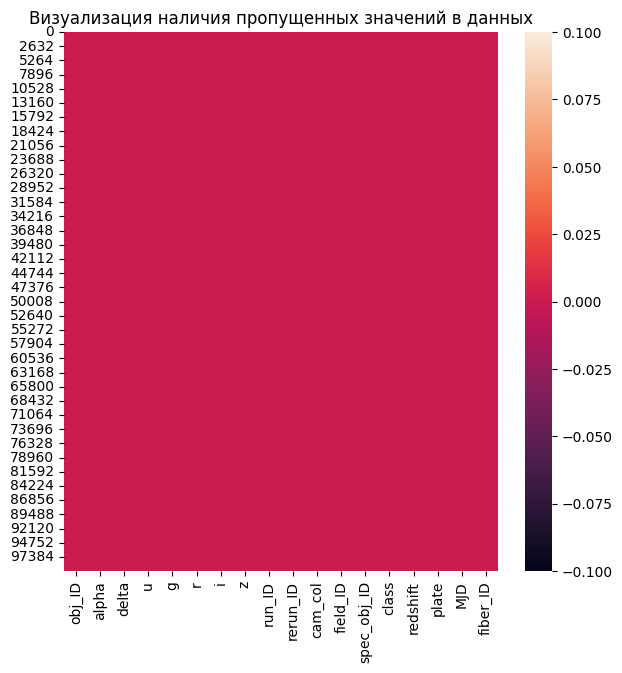

In [ ]:
plt.figure(figsize = (7,7))
sns.heatmap(df.isna(), cbar=True)
plt.title('Визуализация наличия пропущенных значений в данных')
plt.show()

In [ ]:
df.drop(columns=['class'], axis=1).describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


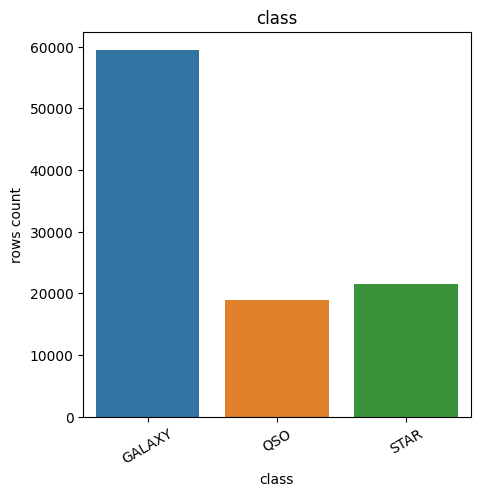

In [ ]:
factor_columns = list(set(df.columns).difference(set(df.describe().columns)))

fig,axes = plt.subplots(len(factor_columns),1,figsize=(5, 5))
for ind,col in enumerate(factor_columns):

    plt.subplot(len(factor_columns),1,ind+1)
    sns.barplot(df,x=col,y="obj_ID", hue="class", estimator='size')
    plt.xticks(rotation=30)
    plt.ylabel("rows count")
    plt.gca().set_title(col)

In [ ]:
df = df.drop(df[df['class'] == 'QSO'].index, axis = 0)

In [ ]:
labenc = LabelEncoder()

In [ ]:
df['class'] = labenc.fit_transform(df['class'])

In [ ]:
X_log = df[list(df.drop(columns=['class'], axis=1).columns)]
y_log = df['class']

In [ ]:
X_log_scaled = StandardScaler().fit_transform(X_log)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_log_scaled, y_log, test_size=0.2, stratify=y_log)

In [ ]:
X_ttrain, X_val, y_ttrain, y_val = train_test_split(X_train, y_train, test_size=0.2/0.8, stratify=y_train)

In [ ]:
model_sm = sm.GLM(y_ttrain, X_ttrain, family=sm.families.Binomial()).fit()

In [ ]:
print(model_sm.pvalues)

x1       6.361659e-119
x2        5.989272e-06
x3        2.083149e-13
x4        1.561593e-04
x5        0.000000e+00
x6        0.000000e+00
x7        1.265492e-52
x8        0.000000e+00
x9       6.361659e-119
const     5.412854e-03
x10      6.361341e-119
x11      6.398452e-119
x12       5.361210e-03
x13       0.000000e+00
x14       5.361210e-03
x15       5.339208e-03
x16       5.361210e-03
dtype: float64


In [ ]:
model_sm = sm.GLM(y_ttrain, X_ttrain, family=sm.families.Binomial()).fit_regularized(L1_wt=0.7, alpha = 0.001)

/usr/local/lib/python3.10/dist-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")


In [ ]:
print(model_sm.params)

x1       0.000000
x2      -0.086201
x3      -0.087304
x4      -1.925354
x5       0.000000
x6       1.471795
x7       0.171862
x8       0.000000
x9      -0.166848
const    0.000000
x10      0.052194
x11     -0.074688
x12     -1.766542
x13     -3.560909
x14      1.252945
x15      1.300028
x16     -0.042823
dtype: float64


In [ ]:
l1_flags = [True if model_sm.params[i]==0 else False for i in range(len(model_sm.params))]

<ipython-input-25-33912944918d>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l1_flags = [True if model_sm.params[i]==0 else False for i in range(len(model_sm.params))]


In [ ]:
X = df.drop(columns=['class'], axis=1)
y = df['class']

In [ ]:
stdenc = StandardScaler()
X_scaled = stdenc.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

In [ ]:
X_ttrain, X_val, y_ttrain, y_val = train_test_split(X_train, y_train, test_size=0.2/0.8, stratify=y_train)

In [ ]:
print(X_ttrain.shape[0]/X.shape[0])

0.5999950641049371


In [ ]:
model_rf, model_lgbm = RandomForestClassifier(), lgbm.LGBMClassifier()

In [ ]:
model_rf.fit(X_ttrain, y_ttrain)

RandomForestClassifier()

In [ ]:
model_lgbm.fit(X_ttrain, y_ttrain)

[LightGBM] [Info] Number of positive: 12956, number of negative: 35667
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3815
[LightGBM] [Info] Number of data points in the train set: 48623, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.266458 -> initscore=-1.012667
[LightGBM] [Info] Start training from score -1.012667


LGBMClassifier()

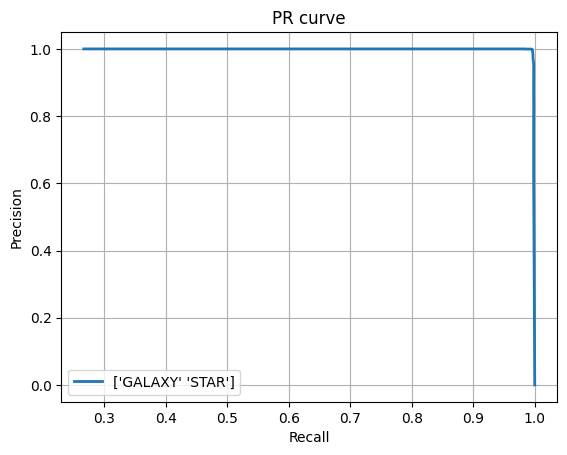

In [ ]:
fpr, tpr, _ = precision_recall_curve(y_val, model_rf.predict_proba(X_val)[:, 1])
plt.plot(fpr, tpr, lw=2, label=labenc.classes_)
roc_auc = auc(tpr, fpr[np.argsort(fpr)])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.legend(loc="best")
plt.title("PR curve")
plt.grid()
plt.show()

In [ ]:
print(f'PR-AUC значение с использованием случайного леса: {roc_auc}')
print(f'F1-мера для случайного леса: {f1_score(y_val, model_rf.predict(X_val))}')

PR-AUC значение с использованием случайного леса: 0.998768354231244
F1-мера для случайного леса: 0.9950443701740233


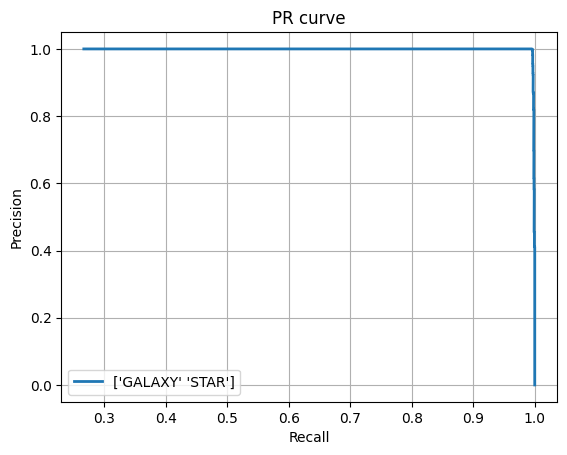

In [ ]:
fpr, tpr, _ = precision_recall_curve(y_val, model_lgbm.predict_proba(X_val)[..., 1])
plt.plot(fpr, tpr, lw=2, label=labenc.classes_)
roc_auc = auc(tpr, fpr[np.argsort(fpr)])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.legend(loc="best")
plt.title("PR curve")
plt.grid()
plt.show()

In [ ]:
print(f'PR-AUC значение с использованием градиентного бустинга: {roc_auc}')
print(f'F1-мера для градиентного бустинга: {f1_score(y_val, model_lgbm.predict(X_val))}')

PR-AUC значение с использованием градиентного бустинга: 0.999038652452451
F1-мера для градиентного бустинга: 0.9973444175037525


In [ ]:
model_rf.feature_importances_

array([0.00650975, 0.00648315, 0.00432628, 0.03201641, 0.03599974,
       0.01232986, 0.01679147, 0.02432052, 0.00530898, 0.        ,
       0.00079777, 0.00236681, 0.03212768, 0.7724555 , 0.02632213,
       0.02000745, 0.00183649])

In [ ]:
model_lgbm.feature_importances_

array([126, 273, 234, 179, 201, 130, 185, 207,  32,   0,  75, 206,  94,
       633,  52, 128, 245], dtype=int32)

In [ ]:
feature_importances_rf = list((model_rf.feature_importances_[i], X.columns[i]) for i in range(len(X.columns)))

In [ ]:
feature_importances_rf

[(0.0065097506681586394, 'obj_ID'),
 (0.006483149879694354, 'alpha'),
 (0.004326284296001464, 'delta'),
 (0.032016412464587425, 'u'),
 (0.03599973658760064, 'g'),
 (0.012329855823170395, 'r'),
 (0.0167914720347429, 'i'),
 (0.024320520315854556, 'z'),
 (0.005308979442924059, 'run_ID'),
 (0.0, 'rerun_ID'),
 (0.0007977733586127293, 'cam_col'),
 (0.0023668142224378304, 'field_ID'),
 (0.03212767974091473, 'spec_obj_ID'),
 (0.7724555007322287, 'redshift'),
 (0.026322131213941155, 'plate'),
 (0.02000744628539662, 'MJD'),
 (0.0018364929337338068, 'fiber_ID')]

In [ ]:
feature_importances_lgbm = list((model_lgbm.feature_importances_[i]/np.sum(model_lgbm.feature_importances_), X.columns[i]) for i in range(len(X.columns)))

In [ ]:
feature_importances_lgbm

[(0.042, 'obj_ID'),
 (0.091, 'alpha'),
 (0.078, 'delta'),
 (0.059666666666666666, 'u'),
 (0.067, 'g'),
 (0.043333333333333335, 'r'),
 (0.06166666666666667, 'i'),
 (0.069, 'z'),
 (0.010666666666666666, 'run_ID'),
 (0.0, 'rerun_ID'),
 (0.025, 'cam_col'),
 (0.06866666666666667, 'field_ID'),
 (0.03133333333333333, 'spec_obj_ID'),
 (0.211, 'redshift'),
 (0.017333333333333333, 'plate'),
 (0.042666666666666665, 'MJD'),
 (0.08166666666666667, 'fiber_ID')]

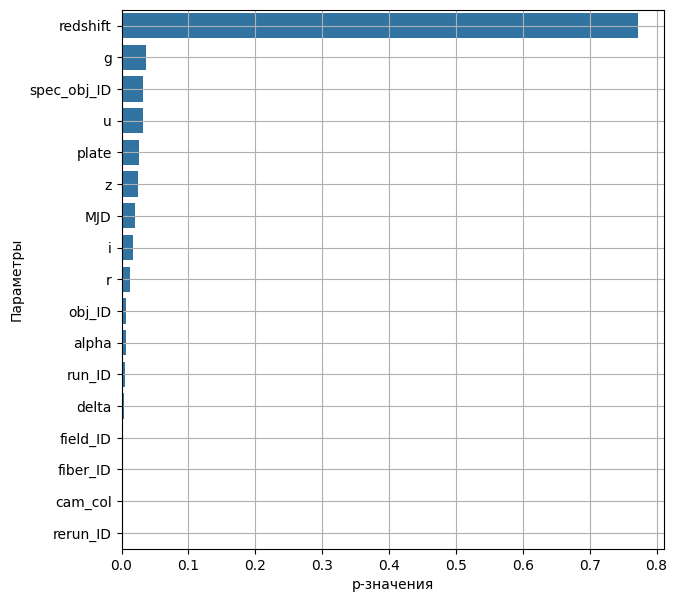

In [ ]:
plt.figure(figsize=(7,7))
sns.barplot(dict(sorted(feature_importances_rf, key = lambda x: x[0], reverse=True)))
plt.xlabel("p-значения")
plt.ylabel("Параметры")
plt.grid()
plt.show()

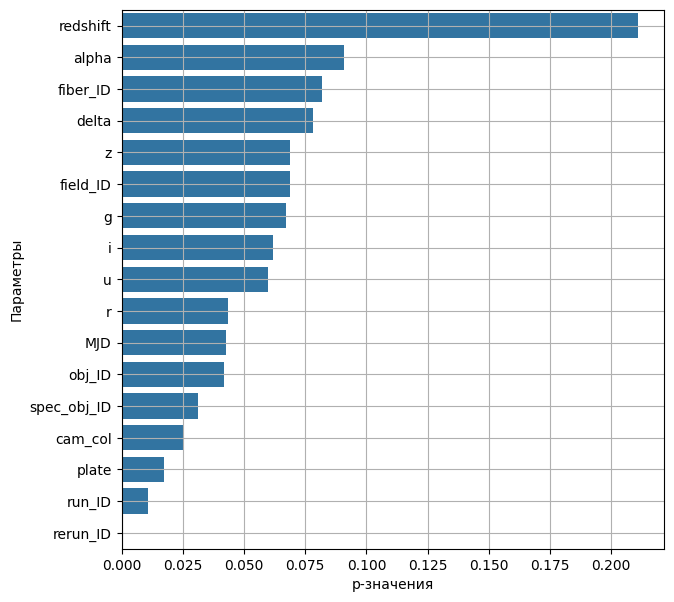

In [ ]:
plt.figure(figsize=(7,7))
sns.barplot(dict(sorted(feature_importances_lgbm, key = lambda x: x[0], reverse=True)))
plt.xlabel("p-значения")
plt.ylabel("Параметры")
plt.grid()
plt.show()

In [ ]:
feature_importances_lgbm, feature_importances_rf = sorted(feature_importances_lgbm, key = lambda x: x[1]), sorted(feature_importances_rf, key = lambda x: x[1])

In [ ]:
flags = list(True if feature_importances_lgbm[i][0] < p_value and feature_importances_rf[i][0] < p_value else False for i in range(len(X.columns)))

In [ ]:
flags

[True,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 False]

In [ ]:
explainer = shap.Explainer(model_rf)
shap_values = explainer(X_val)

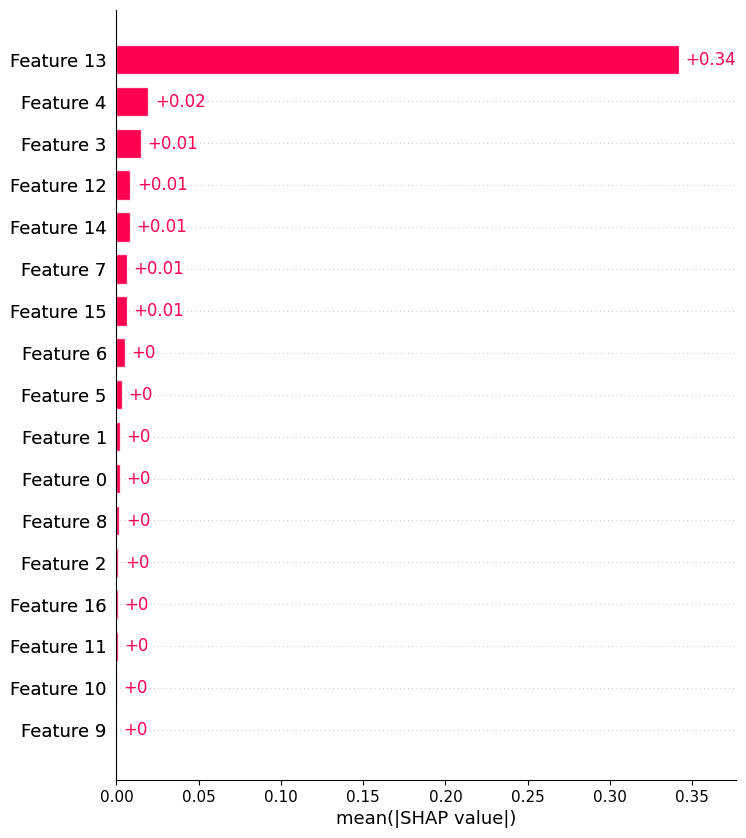

In [ ]:
shap.plots.bar(shap_values[..., 0], max_display=X.shape[1])

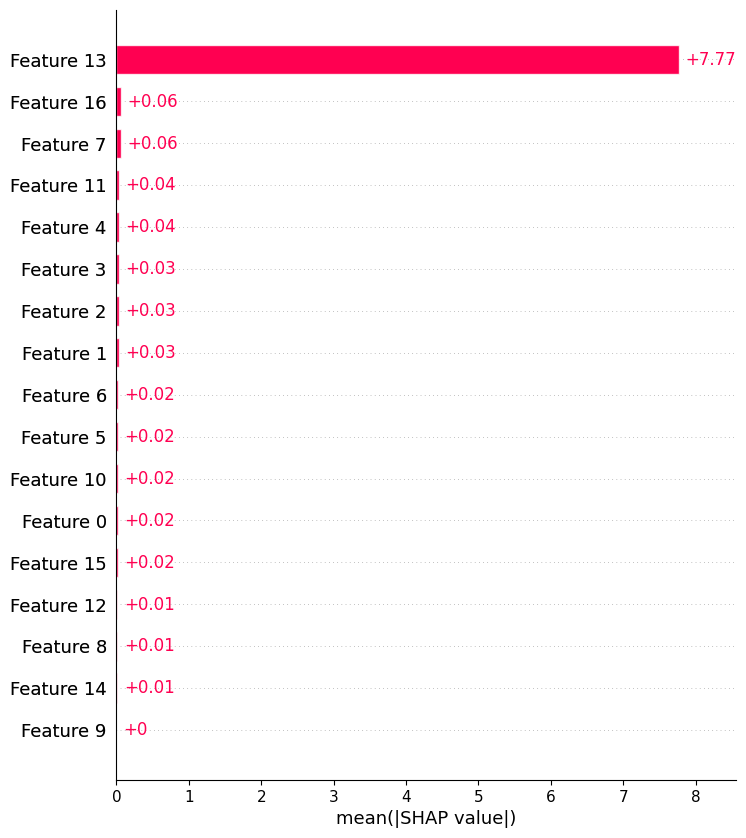

In [ ]:
explainer = shap.Explainer(model_lgbm)
shap_values = explainer(X_val)
shap.plots.bar(shap_values, max_display=X.shape[1])

In [ ]:
shap_flags = [False]*13+[True]+[False]*3

In [ ]:
sfs = SequentialFeatureSelector(model_rf, scoring='roc_auc', cv=3)
sfs.fit(X_ttrain, y_ttrain)

SequentialFeatureSelector(cv=3, estimator=RandomForestClassifier(),
                          scoring='roc_auc')

In [ ]:
rf_flags = sfs.get_support()

In [ ]:
sfs = SequentialFeatureSelector(model_lgbm, scoring='roc_auc', cv=3)
sfs.fit(X_ttrain, y_ttrain)

[LightGBM] [Info] Number of positive: 8637, number of negative: 23778
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 32415, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.266451 -> initscore=-1.012705
[LightGBM] [Info] Start training from score -1.012705
[LightGBM] [Info] Number of positive: 8637, number of negative: 23778
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 32415, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.266451 -> initscore=-1.012705
[LightGBM] [Info] Start training from score -1.012705
[LightGBM] [Info] 

SequentialFeatureSelector(cv=3, estimator=LGBMClassifier(), scoring='roc_auc')

In [ ]:
lgbm_flags = sfs.get_support()

In [ ]:
greedy_flags = np.array(lgbm_flags) * np.array(rf_flags)

In [ ]:
print(greedy_flags)

[False False False False  True  True  True False False False False False
 False  True False False False]


In [ ]:
df_flags = pd.DataFrame({"features":X.columns,"rf_lgbm_flags":flags, "shap_flags":shap_flags, "greedy_flags":greedy_flags, 'l1_flags':l1_flags})

In [ ]:
print(df_flags)

       features  rf_lgbm_flags  shap_flags  greedy_flags  l1_flags
0        obj_ID           True       False         False      True
1         alpha          False       False         False     False
2         delta           True       False         False     False
3             u          False       False         False     False
4             g          False       False          True      True
5             r          False       False          True     False
6             i          False       False          True     False
7             z          False       False         False      True
8        run_ID           True       False         False     False
9      rerun_ID           True       False         False      True
10      cam_col           True       False         False     False
11     field_ID          False       False         False     False
12  spec_obj_ID           True       False         False     False
13     redshift           True        True          True     F

In [ ]:
selected_df_rf_lgbm = df.drop(df_flags['features'][df_flags['rf_lgbm_flags']==True], axis=1)

In [ ]:
selected_df_rf_lgbm

,alpha,u,g,r,i,z,field_ID,class,MJD,fiber_ID
0,135.689107,23.87882,22.27530,20.39501,19.16573,18.79371,79,0,56354,171
1,144.826101,24.77759,22.83188,22.58444,21.16812,21.61427,119,0,58158,427
2,142.188790,25.26307,22.66389,20.60976,19.34857,18.94827,120,0,55592,299
3,338.741038,22.13682,23.77656,21.61162,20.50454,19.25010,214,0,58039,775
4,345.282593,19.43718,17.58028,16.49747,15.97711,15.54461,137,0,56187,842
...,...,...,...,...,...,...,...,...,...,...
99995,39.620709,22.16759,22.97586,21.90404,21.30548,20.73569,581,0,57749,438
99996,29.493819,22.69118,22.38628,20.45003,19.75759,19.41526,289,0,56934,866
99997,224.587407,21.16916,19.26997,18.20428,17.69034,17.35221,308,0,54535,74
99998,212.268621,25.35039,21.63757,19.91386,19.07254,18.62482,131,0,56368,470


In [ ]:
X = selected_df_rf_lgbm.drop(columns=['class'], axis=1)
y = selected_df_rf_lgbm['class']

In [ ]:
stdenc = StandardScaler()
X_scaled = stdenc.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

In [ ]:
X_ttrain, X_val, y_ttrain, y_val = train_test_split(X_train, y_train, test_size=0.2/0.8, stratify=y_train)

In [ ]:
print(X_ttrain.shape[0]/X.shape[0])

0.5999950641049371


In [ ]:
model_rf, model_lgbm = RandomForestClassifier(), lgbm.LGBMClassifier()

In [ ]:
model_rf.fit(X_ttrain, y_ttrain)

RandomForestClassifier()

In [ ]:
model_lgbm.fit(X_ttrain, y_ttrain)

[LightGBM] [Info] Number of positive: 12956, number of negative: 35667
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 48623, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.266458 -> initscore=-1.012667
[LightGBM] [Info] Start training from score -1.012667


LGBMClassifier()

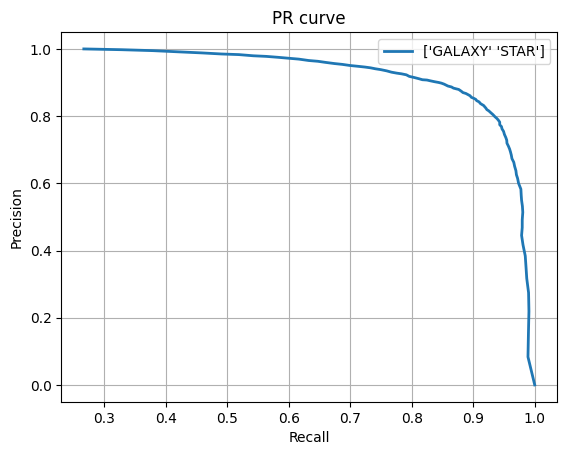

In [ ]:
fpr, tpr, _ = precision_recall_curve(y_val, model_rf.predict_proba(X_val)[:, 1])
plt.plot(fpr, tpr, lw=2, label=labenc.classes_)
roc_auc = auc(tpr, fpr[np.argsort(fpr)])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.legend(loc="best")
plt.title("PR curve")
plt.grid()
plt.show()

In [ ]:
print(f'PR-AUC значение с использованием случайного леса: {roc_auc}')
print(f'F1-мера для случайного леса: {f1_score(y_val, model_rf.predict(X_val))}')

PR-AUC значение с использованием случайного леса: 0.9398637023992897
F1-мера для случайного леса: 0.8747905195116112


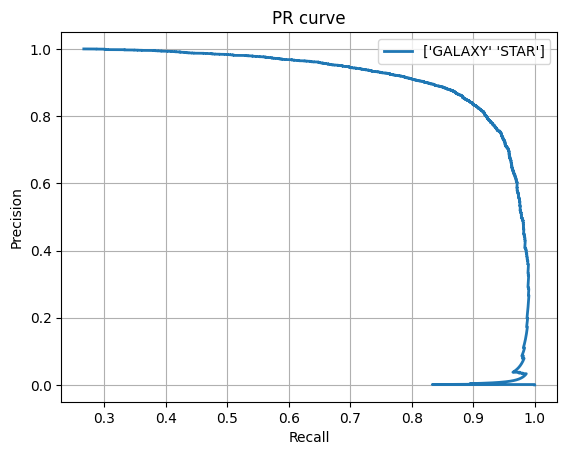

In [ ]:
fpr, tpr, _ = precision_recall_curve(y_val, model_lgbm.predict_proba(X_val)[..., 1])
plt.plot(fpr, tpr, lw=2, label=labenc.classes_)
roc_auc = auc(tpr, fpr[np.argsort(fpr)])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.legend(loc="best")
plt.title("PR curve")
plt.grid()
plt.show()

In [ ]:
print(f'PR-AUC значение с использованием градиентного бустинга: {roc_auc}')
print(f'F1-мера для градиентного бустинга: {f1_score(y_val, model_lgbm.predict(X_val))}')

PR-AUC значение с использованием градиентного бустинга: 0.9334007742438789
F1-мера для градиентного бустинга: 0.8660638939119952


In [ ]:
selected_df_shap = df.drop(df_flags['features'][df_flags['shap_flags']==False], axis=1)

In [ ]:
selected_df_shap

,class,redshift
0,0,0.634794
1,0,0.779136
2,0,0.644195
3,0,0.932346
4,0,0.116123
...,...,...
99995,0,0.000000
99996,0,0.404895
99997,0,0.143366
99998,0,0.455040


In [ ]:
X = selected_df_shap.drop(columns=['class'], axis=1)
y = selected_df_shap['class']

In [ ]:
stdenc = StandardScaler()
X_scaled = stdenc.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

In [ ]:
X_ttrain, X_val, y_ttrain, y_val = train_test_split(X_train, y_train, test_size=0.2/0.8, stratify=y_train)

In [ ]:
print(X_ttrain.shape[0]/X.shape[0])

0.5999950641049371


In [ ]:
model_rf, model_lgbm = RandomForestClassifier(), lgbm.LGBMClassifier()

In [ ]:
model_rf.fit(X_ttrain, y_ttrain)

RandomForestClassifier()

In [ ]:
model_lgbm.fit(X_ttrain, y_ttrain)

[LightGBM] [Info] Number of positive: 12956, number of negative: 35667
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 48623, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.266458 -> initscore=-1.012667
[LightGBM] [Info] Start training from score -1.012667


LGBMClassifier()

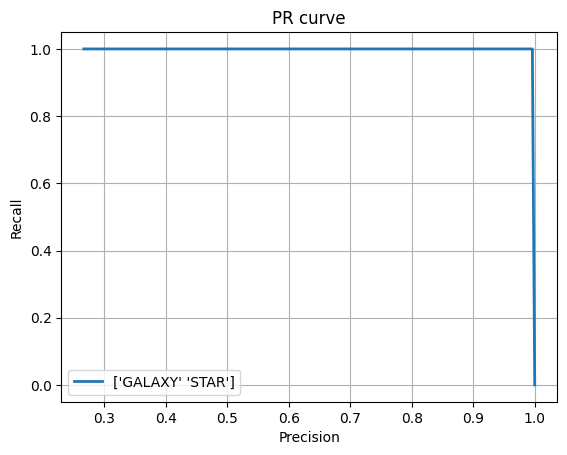

In [ ]:
fpr, tpr, _ = precision_recall_curve(y_val, model_rf.predict_proba(X_val)[:, 1])
plt.plot(fpr, tpr, lw=2, label=labenc.classes_)
roc_auc = auc(tpr, fpr[np.argsort(fpr)])
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="best")
plt.title("PR curve")
plt.grid()
plt.show()

In [ ]:
print(f'PR-AUC значение с использованием случайного леса: {roc_auc}')
print(f'F1-мера для случайного леса: {f1_score(y_val, model_rf.predict(X_val))}')

PR-AUC значение с использованием случайного леса: 0.9980993223020752
F1-мера для случайного леса: 0.9968768074031232


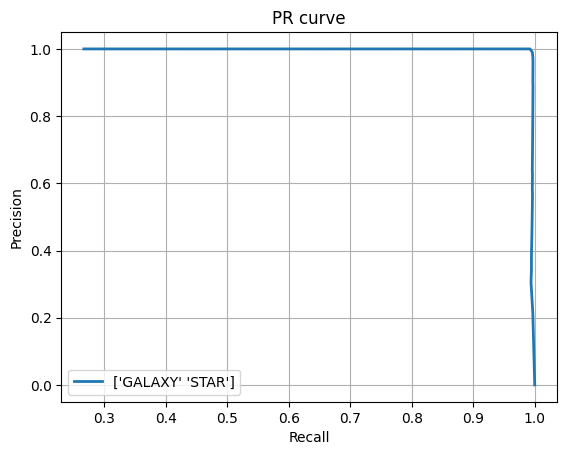

In [ ]:
fpr, tpr, _ = precision_recall_curve(y_val, model_lgbm.predict_proba(X_val)[..., 1])
plt.plot(fpr, tpr, lw=2, label=labenc.classes_)
roc_auc = auc(tpr, fpr[np.argsort(fpr)])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.legend(loc="best")
plt.title("PR curve")
plt.grid()
plt.show()

In [ ]:
print(f'PR-AUC значение с использованием градиентного бустинга: {roc_auc}')
print(f'F1-мера для градиентного бустинга: {f1_score(y_val, model_lgbm.predict(X_val))}')

PR-AUC значение с использованием градиентного бустинга: 0.9969201247832385
F1-мера для градиентного бустинга: 0.9961942105870142


In [ ]:
selected_df_greedy = df.drop(df_flags['features'][df_flags['greedy_flags']==False], axis=1)

In [ ]:
selected_df_greedy

,g,r,i,class,redshift
0,22.27530,20.39501,19.16573,0,0.634794
1,22.83188,22.58444,21.16812,0,0.779136
2,22.66389,20.60976,19.34857,0,0.644195
3,23.77656,21.61162,20.50454,0,0.932346
4,17.58028,16.49747,15.97711,0,0.116123
...,...,...,...,...,...
99995,22.97586,21.90404,21.30548,0,0.000000
99996,22.38628,20.45003,19.75759,0,0.404895
99997,19.26997,18.20428,17.69034,0,0.143366
99998,21.63757,19.91386,19.07254,0,0.455040


In [ ]:
X = selected_df_greedy.drop(columns=['class'], axis=1)
y = selected_df_greedy['class']

In [ ]:
stdenc = StandardScaler()
X_scaled = stdenc.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

In [ ]:
X_ttrain, X_val, y_ttrain, y_val = train_test_split(X_train, y_train, test_size=0.2/0.8, stratify=y_train)

In [ ]:
print(X_ttrain.shape[0]/X.shape[0])

0.5999950641049371


In [ ]:
model_rf, model_lgbm = RandomForestClassifier(), lgbm.LGBMClassifier()

In [ ]:
model_rf.fit(X_ttrain, y_ttrain)

RandomForestClassifier()

In [ ]:
model_lgbm.fit(X_ttrain, y_ttrain)

[LightGBM] [Info] Number of positive: 12956, number of negative: 35667
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002305 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 48623, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.266458 -> initscore=-1.012667
[LightGBM] [Info] Start training from score -1.012667


LGBMClassifier()

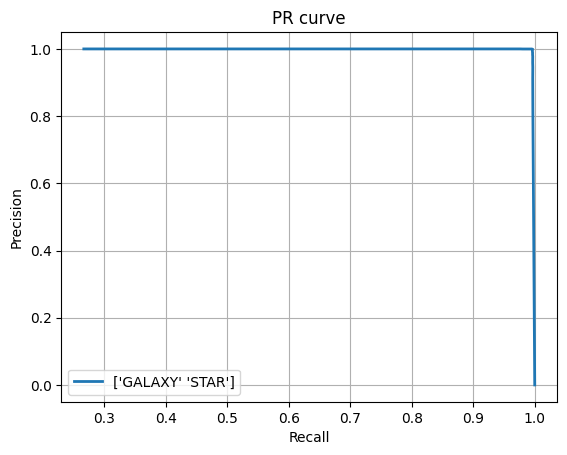

In [ ]:
fpr, tpr, _ = precision_recall_curve(y_val, model_rf.predict_proba(X_val)[:, 1])
plt.plot(fpr, tpr, lw=2, label=labenc.classes_)
roc_auc = auc(tpr, fpr[np.argsort(fpr)])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.legend(loc="best")
plt.title("PR curve")
plt.grid()
plt.show()

In [ ]:
print(f'PR-AUC значение с использованием случайного леса: {roc_auc}')
print(f'F1-мера для случайного леса: {f1_score(y_val, model_rf.predict(X_val))}')

PR-AUC значение с использованием случайного леса: 0.9981630431307702
F1-мера для случайного леса: 0.9976889299745783


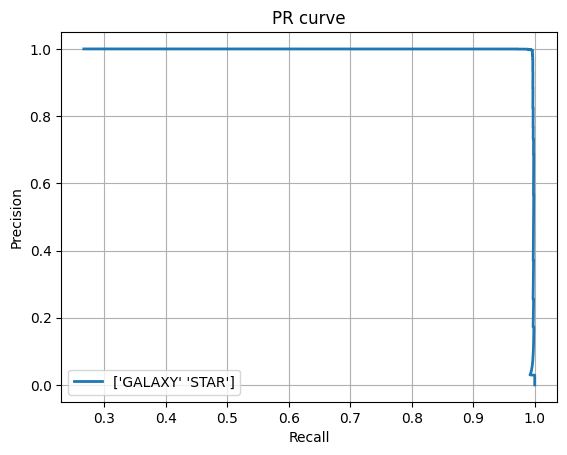

In [ ]:
fpr, tpr, _ = precision_recall_curve(y_val, model_lgbm.predict_proba(X_val)[..., 1])
plt.plot(fpr, tpr, lw=2, label=labenc.classes_)
roc_auc = auc(tpr, fpr[np.argsort(fpr)])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.legend(loc="best")
plt.title("PR curve")
plt.grid()
plt.show()

In [ ]:
print(f'PR-AUC значение с использованием градиентного бустинга: {roc_auc}')
print(f'F1-мера для градиентного бустинга: {f1_score(y_val, model_lgbm.predict(X_val))}')

PR-AUC значение с использованием градиентного бустинга: 0.9977757679047892
F1-мера для градиентного бустинга: 0.9949215143120961


In [ ]:
selected_df_l1 = df.drop(df_flags['features'][df_flags['l1_flags']==True], axis=1)

In [ ]:
selected_df_l1

,alpha,delta,u,r,i,run_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,135.689107,32.494632,23.87882,20.39501,19.16573,3606,2,79,6.543777e+18,0,0.634794,5812,56354,171
1,144.826101,31.274185,24.77759,22.58444,21.16812,4518,5,119,1.176014e+19,0,0.779136,10445,58158,427
2,142.188790,35.582444,25.26307,20.60976,19.34857,3606,2,120,5.152200e+18,0,0.644195,4576,55592,299
3,338.741038,-0.402828,22.13682,21.61162,20.50454,4192,3,214,1.030107e+19,0,0.932346,9149,58039,775
4,345.282593,21.183866,19.43718,16.49747,15.97711,8102,3,137,6.891865e+18,0,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,21.90404,21.30548,7778,2,581,1.055431e+19,0,0.000000,9374,57749,438
99996,29.493819,19.798874,22.69118,20.45003,19.75759,7917,1,289,8.586351e+18,0,0.404895,7626,56934,866
99997,224.587407,15.700707,21.16916,18.20428,17.69034,5314,4,308,3.112008e+18,0,0.143366,2764,54535,74
99998,212.268621,46.660365,25.35039,19.91386,19.07254,3650,4,131,7.601080e+18,0,0.455040,6751,56368,470


In [ ]:
X = selected_df_l1.drop(columns=['class'], axis=1)
y = selected_df_l1['class']

In [ ]:
stdenc = StandardScaler()
X_scaled = stdenc.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

In [ ]:
X_ttrain, X_val, y_ttrain, y_val = train_test_split(X_train, y_train, test_size=0.2/0.8, stratify=y_train)

In [ ]:
print(X_ttrain.shape[0]/X.shape[0])

0.5999950641049371


In [ ]:
model_rf, model_lgbm = RandomForestClassifier(), lgbm.LGBMClassifier()

In [ ]:
model_rf.fit(X_ttrain, y_ttrain)

RandomForestClassifier()

In [ ]:
model_lgbm.fit(X_ttrain, y_ttrain)

[LightGBM] [Info] Number of positive: 12956, number of negative: 35667
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3049
[LightGBM] [Info] Number of data points in the train set: 48623, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.266458 -> initscore=-1.012667
[LightGBM] [Info] Start training from score -1.012667


LGBMClassifier()

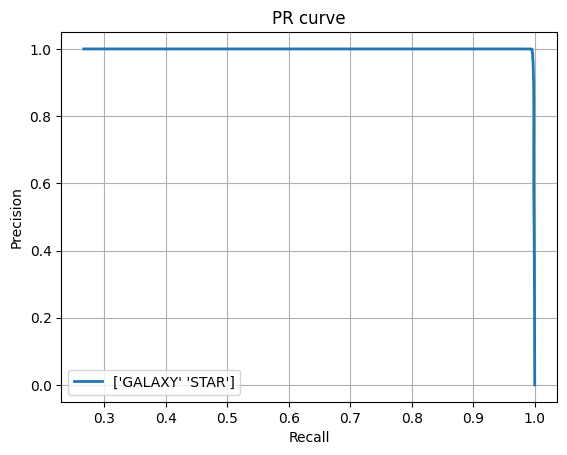

In [ ]:
fpr, tpr, _ = precision_recall_curve(y_val, model_rf.predict_proba(X_val)[:, 1])
plt.plot(fpr, tpr, lw=2, label=labenc.classes_)
roc_auc = auc(tpr, fpr[np.argsort(fpr)])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.legend(loc="best")
plt.title("PR curve")
plt.grid()
plt.show()

In [ ]:
print(f'PR-AUC значение с использованием случайного леса: {roc_auc}')
print(f'F1-мера для случайного леса: {f1_score(y_val, model_rf.predict(X_val))}')

PR-AUC значение с использованием случайного леса: 0.9988945556554479
F1-мера для случайного леса: 0.994701681640175


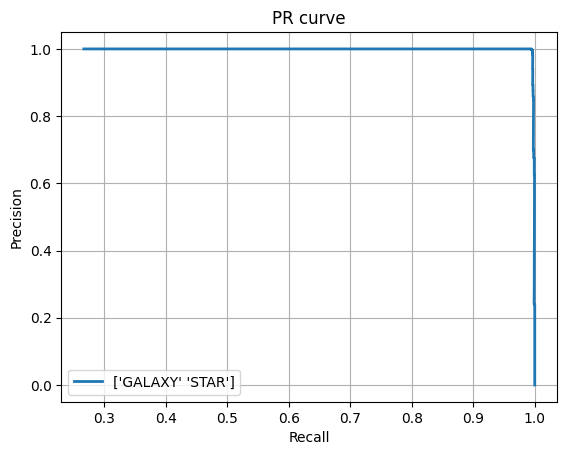

In [ ]:
fpr, tpr, _ = precision_recall_curve(y_val, model_lgbm.predict_proba(X_val)[..., 1])
plt.plot(fpr, tpr, lw=2, label=labenc.classes_)
roc_auc = auc(tpr, fpr[np.argsort(fpr)])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.legend(loc="best")
plt.title("PR curve")
plt.grid()
plt.show()

In [ ]:
print(f'PR-AUC значение с использованием градиентного бустинга: {roc_auc}')
print(f'F1-мера для градиентного бустинга: {f1_score(y_val, model_lgbm.predict(X_val))}')

PR-AUC значение с использованием градиентного бустинга: 0.9989101118179216
F1-мера для градиентного бустинга: 0.9971121635670556


In [ ]:
X = df.drop(columns=['class'], axis=1)
y = df['class']

In [ ]:
stdenc = StandardScaler()
X_scaled = stdenc.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

In [ ]:
X_ttrain, X_val, y_ttrain, y_val = train_test_split(X_train, y_train, test_size=0.2/0.8, stratify=y_train)

In [ ]:
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_scaled)

In [ ]:
X_tsne.shape

(81039, 2)

In [ ]:
pca_df = PCA(n_components=2).fit_transform(df.drop(columns=['class']))

In [ ]:
pca_df

array([[ 1.23567046e+18, -4.49144359e+12],
       [ 6.45203513e+18, -4.08843399e+12],
       [-1.55906653e+17, -3.55357554e+12],
       ...,
       [-2.19609915e+18,  5.15831993e+12],
       [ 2.29297266e+18, -5.01396578e+12],
       [ 3.03504544e+18, -5.51409676e+12]])

In [ ]:
r = lambda: random.randint(0, 255)
colors = ['#%02X%02X%02X' % (r(), r(), r())\
          for i in range(len(np.unique(df['class'])))]
temp_df = pd.DataFrame({'PCA1':pca_df[:, 0], 'PCA2':pca_df[:, 1],\
                        'colors': [colors[i%len(np.unique(df['class']))] \
                                   for i in df['class']],\
                        'label':[labenc.classes_[i%len(np.unique(df['class']))]\
                                 for i in df['class']]})

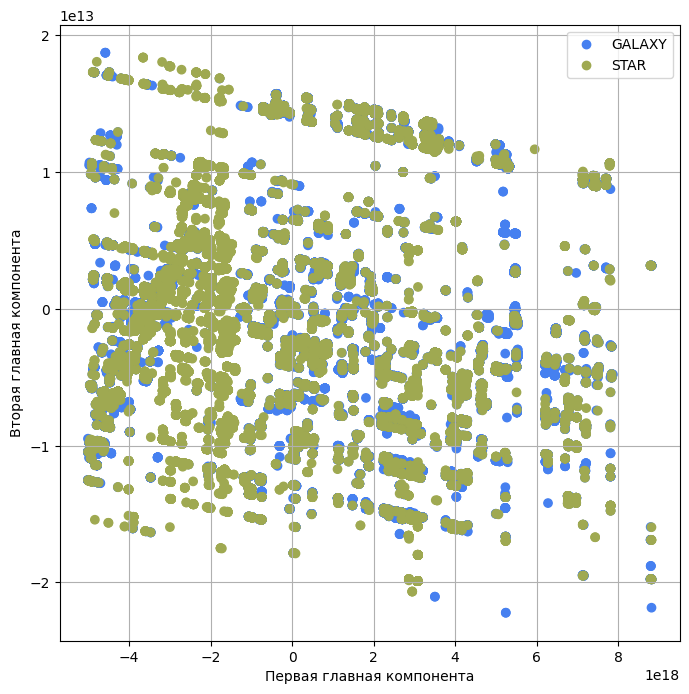

In [ ]:
plt.figure(figsize=(8, 8))
for i in np.unique(temp_df['label']):
  plt.scatter(temp_df['PCA1'][temp_df['label']==i], \
              temp_df['PCA2'][temp_df['label']==i],\
              c=temp_df['colors'][temp_df['label']==i], label = i)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend()
plt.grid()
plt.show()

In [ ]:
temp_df = pd.DataFrame({'TSNE1':X_tsne[:, 0], 'TSNE2':X_tsne[:, 1], 'colors': [colors[i%len(np.unique(df['class']))] for i in df['class']], 'label':\
                        [labenc.classes_[i%len(np.unique(df['class']))] for i in df['class']]})

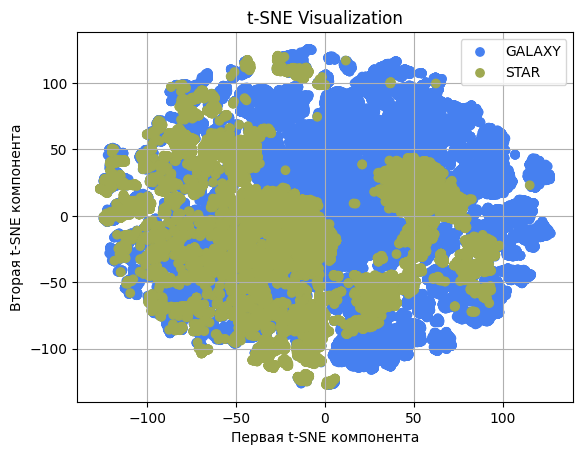

In [ ]:
for i in np.unique(temp_df['label']):
  plt.scatter(temp_df['TSNE1'][temp_df['label']==i], \
              temp_df['TSNE2'][temp_df['label']==i],\
              c=temp_df['colors'][temp_df['label']==i], label = i)
plt.title("t-SNE Visualization")
plt.xlabel('Первая t-SNE компонента')
plt.ylabel('Вторая t-SNE компонента')
plt.legend()
plt.grid()
plt.show()